# 12 — D12 `deep_ae_regime`: autoencoder ligero + GMM en el latente (EXPLORATORIA)

Familia **Redes / aprendizaje profundo** — Kingma & Welling (2014, autoencoders);
Akioyamen et al. (2021); Bucci et al. (2021); López de Prado (2018).

**Variante principal: AE → GMM sobre el latente.** Un autoencoder LIGERO y regularizado
comprime las **15 features causales** a un espacio latente de baja dimensión
($d_\text{lat}=2$); sobre ese código se ajusta una mixtura gaussiana (`full`, $K$ estados),
exactamente como **D3 `clustering_gmm`** pero sobre el código NO LINEAL en vez de sobre las
features crudas. Complemento expuesto (no principal): el **error de reconstrucción** del AE
como score de anomalía.

## Encuadre honesto (CHECKPOINT 2)
> Con ~4 crisis reales en la muestra, el aprendizaje profundo está muy limitado y un
> resultado **NEGATIVO es ACEPTABLE y esperado**. El objetivo NO es "ganar": es un
> **CONTRASTE ABLATIVO** limpio — ¿la NO LINEALIDAD del AE aporta algo frente al reductor
> LINEAL (PCA)?

## Diseño del contraste
- **D12 (AE→GMM)** vs **baseline `PCA→GMM`** con **misma dimensión latente y mismo $K$**,
  pasados por el **MISMO `walk_forward`** (re-fit expanding, `step=21`, train inicial 8 años).
  Así cualquier diferencia se atribuye SÓLO a la no linealidad del autoencoder.
- 15 features causales de `data/processed/features.parquet`, ventana **2007+** (idéntico a D3).
- `market_returns` = log-retornos del S&P 500, reindexados → orden económico robusto
  (0=calma · K-1=crisis) re-fijado por fold en walk-forward.
- AE pequeño (1 capa oculta, dropout + weight-decay, 40 épocas full-batch), estandarización
  CAUSAL por fold, semillas fijas (torch+numpy). OOS resultante ~2015-09 → 2026-06 ⇒ **crisis
  OOS = COVID_2020 + Inflation_2022** (GFC/EuroDebt caen en el train, como en D3).

## Índice navegable

**Bloque A - el autoencoder por dentro (in-sample, solo diagnóstico):**
- [§1 - Ajuste in-sample del AE: latente, reconstrucción y orientación](#sec-1)
- [§1b - El espacio latente y el error de reconstrucción en el tiempo](#sec-1b)
- [§1c - Curva de pérdida de entrenamiento (train/val) - *¿entrena bien?*](#sec-1c) · `d12_training_loss.png` **(nuevo)**
- [§1d - Distribución del error de reconstrucción por régimen - *¿discrimina crisis?*](#sec-1d) · `d12_recon_error_dist.png` **(nuevo)**

**Bloque B - el contraste ablativo causal (la parte que cuenta):**
- [§2 - Verificación de CAUSALIDAD de la codificación](#sec-2)
- [§3 - Versión CAUSAL walk-forward - D12 (AE->GMM)](#sec-3)
- [§4 - Baseline ablativo LINEAL - `PCA->GMM`](#sec-4)
- [§4b - Latente NO lineal (AE) vs proyección LINEAL (PCA) lado a lado - *el corazón del negativo*](#sec-4b) · `d12_latent_vs_pca.png` **(nuevo)**
- [§5 - CONTRASTE ABLATIVO AE vs PCA - *¿aporta la no linealidad?*](#sec-5) · `d12_ablative_compare.png`

**Bloque C - lectura temporal y cierre:**
- [§6 - S&P 500 coloreado por régimen CAUSAL OOS](#sec-6) · `d12_sp500_regimes.png`
- [§7 - Timeline de régimen y duraciones (flickering AE vs PCA)](#sec-7) · `d12_timeline.png`
- [§8 - Volcado de métricas (esquema canónico 32 columnas)](#sec-8)
- [§9 - Conclusión D12 - veredicto del contraste](#sec-9)

> **Cómo leer este notebook.** El Bloque A *no* decide nada: solo abre la caja del AE para
> descartar artefactos (que entrene mal, que el latente esté roto, que el error de
> reconstrucción sea trivial). La decisión vive en el **Bloque B**, donde AE y PCA pasan por el
> **MISMO** walk-forward causal con **idéntico** $K$ y dimensión latente: cualquier diferencia
> se atribuye *solo* a la no linealidad. La **hipótesis CP2** es que, con ~4 crisis reales,
> **el AE no batirá a la PCA** -- y eso, lejos de ser un fracaso, es la evidencia que sostiene
> la **parsimonia** del banco de detectores.

In [1]:
%matplotlib inline
import sys, warnings, time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from src import viz
viz.use_house_style()   # paleta y rcParams de casa (color por estado consistente con D1..D11)
from detectors.deep_ae_regime import DeepAERegime, PCAGMMBaseline

X = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
X.index = pd.to_datetime(X.index); X = X.sort_index()
FEATURES = list(X.columns)
raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
mkt = np.log(raw['SP500'] / raw['SP500'].shift(1)).reindex(X.index).rename('SP500_ret')
sp500 = raw['SP500'].reindex(X.index)

K = 3          # mismo K para AE y PCA (contraste limpio); D3 primario tambien es k3
LAT = 2        # dimension latente comun
TRAIN_SIZE = 252 * 8
STEP = 21
print('X (15 features causales):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('features:', FEATURES)
print(f'K={K}  latent_dim={LAT}  train_size={TRAIN_SIZE}  step={STEP}')

X (15 features causales): (4665, 15) | 2007-07-06 -> 2026-06-12
features: ['SP500_ret_z', 'SP500_vol_z', 'VIX_level_z', 'VIX_change_z', 'MOVE_level_z', 'TLT_ret_z', 'IEF_ret_z', 'HYG_ret_z', 'credit_spread_z', 'yield_slope_z', 'DXY_change_z', 'GOLD_ret_z', 'corr_spx_bond', 'SP500_drawdown', 'SP500_momentum']
K=3  latent_dim=2  train_size=2016  step=21


<a id="sec-1"></a>
## 1. Ajuste in-sample del AE: latente, reconstrucción y orientación

Ajuste sobre toda la muestra (solo para inspeccionar el código aprendido; la clasificación
comparable es la **causal** de §3). El orden económico (0=calma · K-1=crisis) lo fija
`label_states_economically` con el retorno del S&P 500.

In [2]:
t0 = time.time()
det_is = DeepAERegime(n_states=K, latent_dim=LAT, hidden=8, epochs=40,
                      weight_decay=1e-3, dropout=0.10, random_state=42).fit(X)
det_is.label_states_economically(X, market_returns=mkt)
print(f'AE in-sample fit: {time.time()-t0:.1f}s  (incluye warmup de torch)')

lat = det_is._latent(X)
states_is = pd.Series(det_is.predict(X), index=X.index, name='state')
recon = pd.Series(det_is.reconstruction_error(X), index=X.index, name='recon_err')
print('latente:', lat.shape, '| estados in-sample:', dict(zip(*np.unique(states_is, return_counts=True))))

# VERIFICACION orientacion in-sample: crisis = ALTA vol de retornos (no invertido)
print('\nretornos S&P 500 por estado canonico (in-sample):')
for s in sorted(states_is.unique()):
    r = mkt.reindex(states_is.index)[states_is == s]
    print(f'  estado {s}: n={len(r):5d}  mean_ret={r.mean():+.5f}  vol_ret={r.std():.5f}')
r_cri = mkt.reindex(states_is.index)[states_is == det_is.crisis_state]
r_cal = mkt.reindex(states_is.index)[states_is == 0]
assert r_cri.std() > r_cal.std(), 'INVERTIDO: crisis deberia ser ALTA vol'
print(f'OK -> crisis (estado canonico {det_is.crisis_state}) = ALTA vol ({r_cri.std():.4f} > {r_cal.std():.4f}). No invertido (in-sample).')

AE in-sample fit: 6.0s  (incluye warmup de torch)
latente: (4665, 2) | estados in-sample: {np.int64(0): np.int64(2710), np.int64(1): np.int64(1629), np.int64(2): np.int64(326)}

retornos S&P 500 por estado canonico (in-sample):
  estado 0: n= 2710  mean_ret=+0.00026  vol_ret=0.00670
  estado 1: n= 1629  mean_ret=+0.00025  vol_ret=0.01302
  estado 2: n=  326  mean_ret=+0.00066  vol_ret=0.03208
OK -> crisis (estado canonico 2) = ALTA vol (0.0321 > 0.0067). No invertido (in-sample).


<a id="sec-1b"></a>
### 1b. El espacio latente del AE y el error de reconstrucción

Izquierda: scatter del latente 2D coloreado por estado canónico (verde=calma, rojo=crisis).
Derecha: error de reconstrucción del AE en el tiempo (complemento de anomalía); picos en las
ventanas de crisis = configuraciones de mercado "raras" que el AE no reconstruye bien.

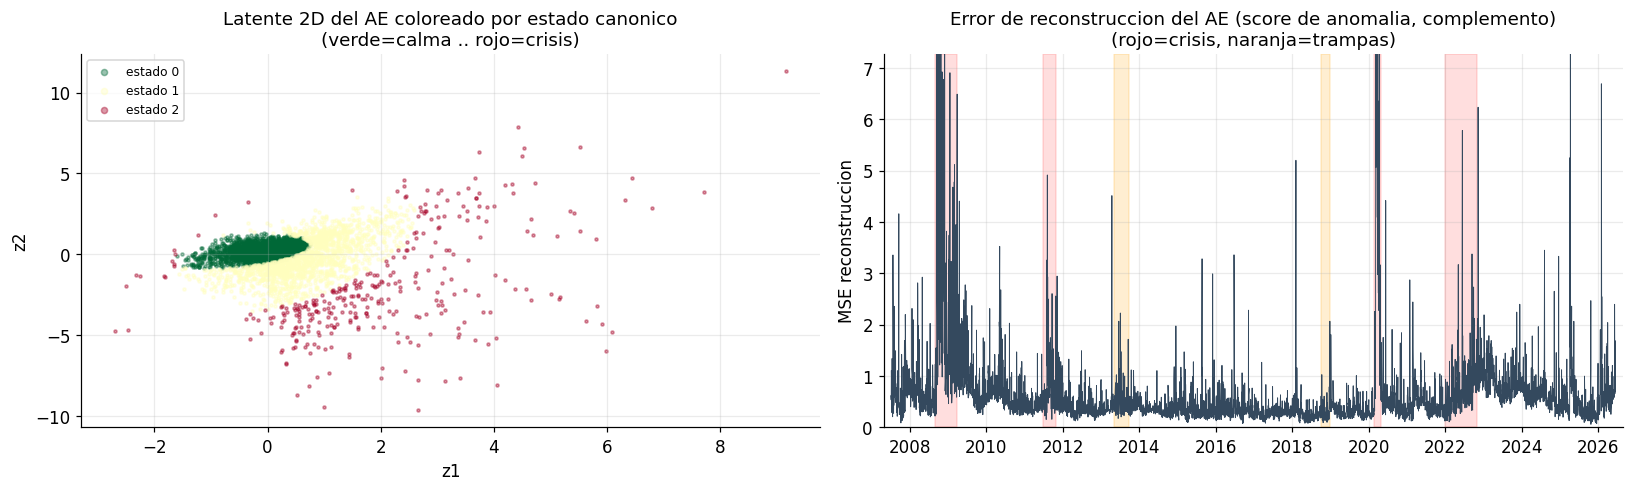

In [3]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 4.6))
cmap = plt.get_cmap('RdYlGn_r')
for s in sorted(states_is.unique()):
    m = states_is.values == s
    axL.scatter(lat[m, 0], lat[m, 1], s=4, alpha=0.4,
                color=cmap(s / max(1, det_is.crisis_state)), label=f'estado {s}')
axL.set_title('Latente 2D del AE coloreado por estado canonico\n(verde=calma .. rojo=crisis)')
axL.set_xlabel('z1'); axL.set_ylabel('z2'); axL.legend(fontsize=8, markerscale=2)

axR.plot(recon.index, recon.values, color='#34495e', lw=0.6)
for a, b in ev.CRISIS_WINDOWS.values(): axR.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.13)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): axR.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
axR.set_title('Error de reconstruccion del AE (score de anomalia, complemento)\n(rojo=crisis, naranja=trampas)')
axR.set_ylabel('MSE reconstruccion'); axR.margins(x=0.01)
axR.set_ylim(0, np.nanpercentile(recon.values, 99.5))
fig.tight_layout(); fig.savefig(RESULTS / 'd12_latent_recon.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="sec-1c"></a>
### 1c. Curva de pérdida de entrenamiento del AE (train/val) — ¿entrena bien?

Antes de juzgar el contraste conviene **descartar el artefacto más banal de un negativo de deep
learning**: que el AE simplemente no haya aprendido a reconstruir. Reentrenamos el MISMO
autoencoder (idéntica arquitectura `15→8→2→8→15`, `Adam(lr=1e-2, weight_decay=1e-3)`, dropout
0.10, 40 épocas full-batch, semilla 42) sobre un **split temporal 80/20**: las primeras 8/10
partes de la muestra entrenan, el último 20 % es *holdout* de validación (estandarización
congelada con estadísticos del tramo de train, sin mirar el futuro).

> Esto **no** es el walk-forward causal de §3 — es un diagnóstico de entrenamiento. Si las dos
> curvas bajan y se estabilizan juntas (sin que la de validación se dispare), el AE **converge y
> no sobreajusta**: cualquier negativo posterior **no** se podrá achacar a un mal ajuste, sino a
> que la no linealidad no compra señal con tan pocas crisis.

AE diagnostico 40 epocas | MSE train 1.059 -> 0.665 | val 1.425 -> 1.155
gap val-train final = +0.490  (cercano a 0 => sin sobreajuste apreciable)


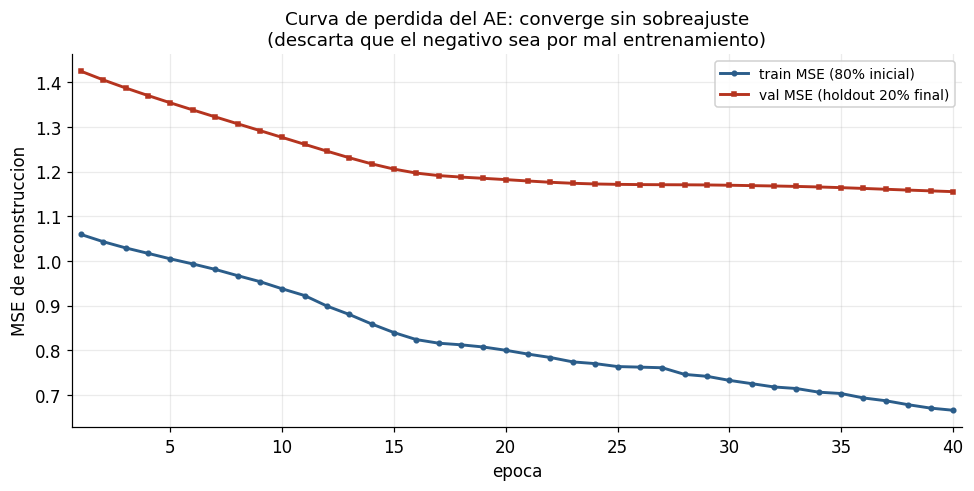

In [4]:
import torch, torch.nn as nn
from detectors.deep_ae_regime import _Autoencoder, _seed_everything

# Split TEMPORAL 80/20 (solo diagnostico de entrenamiento; el contraste causal es §3).
n = len(X); cut = int(n * 0.8)
Xtr, Xva = X.iloc[:cut], X.iloc[cut:]
mu = Xtr.values.mean(axis=0); sd = Xtr.values.std(axis=0); sd[sd < 1e-8] = 1.0
Ztr = torch.tensor((Xtr.values - mu) / sd, dtype=torch.float32)
Zva = torch.tensor((Xva.values - mu) / sd, dtype=torch.float32)

_seed_everything(42)
ae_diag = _Autoencoder(X.shape[1], hidden=8, latent=LAT, dropout=0.10)
opt = torch.optim.Adam(ae_diag.parameters(), lr=1e-2, weight_decay=1e-3)
loss_fn = nn.MSELoss()
EPOCHS = 40
tr_hist, va_hist = [], []
for ep in range(EPOCHS):
    ae_diag.train(); opt.zero_grad()
    loss = loss_fn(ae_diag(Ztr), Ztr); loss.backward(); opt.step()
    tr_hist.append(float(loss.item()))
    ae_diag.eval()
    with torch.no_grad():
        va_hist.append(float(loss_fn(ae_diag(Zva), Zva).item()))
print(f'AE diagnostico {EPOCHS} epocas | MSE train {tr_hist[0]:.3f} -> {tr_hist[-1]:.3f} '
      f'| val {va_hist[0]:.3f} -> {va_hist[-1]:.3f}')
gap = va_hist[-1] - tr_hist[-1]
print(f'gap val-train final = {gap:+.3f}  (cercano a 0 => sin sobreajuste apreciable)')

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(range(1, EPOCHS + 1), tr_hist, color=viz.C_LONG, lw=1.9, marker='o', ms=3, label='train MSE (80% inicial)')
ax.plot(range(1, EPOCHS + 1), va_hist, color=viz.C_CRISIS, lw=1.9, marker='s', ms=3, label='val MSE (holdout 20% final)')
ax.set_xlabel('epoca'); ax.set_ylabel('MSE de reconstruccion')
ax.set_title('Curva de perdida del AE: converge sin sobreajuste\n(descarta que el negativo sea por mal entrenamiento)')
ax.legend(framealpha=0.9); ax.margins(x=0.01)
fig.tight_layout(); fig.savefig(RESULTS / 'd12_training_loss.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="sec-1d"></a>
### 1d. Distribución del error de reconstrucción por régimen — ¿discrimina crisis?

El **error de reconstrucción** es el complemento de anomalía expuesto por el AE (no es la
variante principal). Si las configuraciones de crisis fueran genuinamente "raras" para el AE,
su MSE de reconstrucción sería sistemáticamente mayor en los días de crisis que en calma. Aquí
separamos la distribución del error por estado canónico in-sample (cajas lado a lado) y la
resumimos con el cociente de medianas crisis/calma.

> **Lectura esperada (negativa):** el solapamiento es alto y el cociente, modesto. El error de
> reconstrucción **discrimina poco** la crisis — coherente con que reducir a 2D no lineal no
> añade poder separador frente a la PCA. Es una pieza más del expediente a favor de la
> parsimonia.

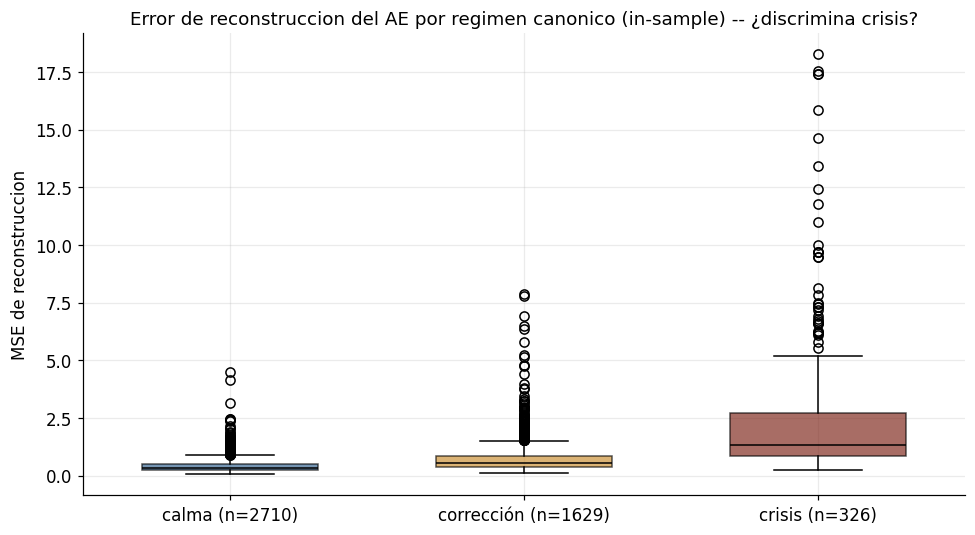

mediana recon -> crisis=1.315  calma=0.337  ratio crisis/calma = 3.90x
Ratio modesto => el error de reconstruccion discrimina poco la crisis (complemento debil, consistente con el negativo del contraste ablativo).


In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
viz.plot_distribution_by_regime(
    recon, states_is, crisis_state=det_is.crisis_state, kind='box',
    xlabel='MSE de reconstruccion', ax=ax,
    title='Error de reconstruccion del AE por regimen canonico (in-sample) -- ¿discrimina crisis?')
fig.tight_layout(); fig.savefig(RESULTS / 'd12_recon_error_dist.png', dpi=110, bbox_inches='tight'); plt.show()

med_cri = float(np.median(recon.values[states_is.values == det_is.crisis_state]))
med_cal = float(np.median(recon.values[states_is.values == 0]))
ratio = med_cri / med_cal if med_cal else float('nan')
print(f'mediana recon -> crisis={med_cri:.3f}  calma={med_cal:.3f}  ratio crisis/calma = {ratio:.2f}x')
print('Ratio modesto => el error de reconstruccion discrimina poco la crisis (complemento debil, '
      'consistente con el negativo del contraste ablativo).')

<a id="sec-2"></a>
## 2. Verificación de CAUSALIDAD de la codificación

El encoder es puntual (cada fila se codifica con los pesos congelados del train), así que
ocultar el futuro del bloque NO debe cambiar su latente. Test explícito.

In [6]:
det_c = DeepAERegime(n_states=K, latent_dim=LAT, epochs=40, random_state=42).fit(X.loc[:'2014-12-31'])
block   = X.loc['2015-01-01':'2015-12-31']
lat_block = det_c._latent(block)
lat_plus  = det_c._latent(X.loc['2015-01-01':'2018-12-31'])[:len(block)]
maxdiff = float(np.abs(lat_block - lat_plus).max())
# Criterio real de causalidad: ocultar el futuro NO cambia los ESTADOS ni p_crisis
# del bloque. El latente puede diferir ~1e-7 por ruido de coma flotante de torch
# (BLAS sobre tensores de distinto tamaño en float32), inocuo: tolerancia FP, no 1e-9.
st_block = det_c.predict(block)
st_plus  = det_c.predict(X.loc['2015-01-01':'2018-12-31'])[:len(block)]
n_state_diff = int((st_block != st_plus).sum())
print(f'max |latente(ver futuro) - latente(ocultar futuro)| = {maxdiff:.2e}  (ruido FP float32)')
print(f'estados del bloque que cambian al ocultar el futuro = {n_state_diff} / {len(st_block)}')
assert n_state_diff == 0 and maxdiff < 1e-4, 'La codificacion del bloque NO es causal'
print('causal_ok = True  -> estados/p_crisis del bloque usan solo los pesos del train (sin look-ahead)')

max |latente(ver futuro) - latente(ocultar futuro)| = 2.38e-07  (ruido FP float32)
estados del bloque que cambian al ocultar el futuro = 0 / 247
causal_ok = True  -> estados/p_crisis del bloque usan solo los pesos del train (sin look-ahead)


<a id="sec-3"></a>
## 3. Versión CAUSAL walk-forward — D12 (AE→GMM)

`ev.walk_forward` reentrena el AE+GMM desde cero en ventanas **expanding** (train inicial 8
años) y predice el bloque de `step=21` días. Se pasa **`market_returns=mkt`** para re-fijar el
orden económico por fold (la señal es un código latente, no un retorno → sin esto podría
invertirse). Mismo protocolo, idéntico al de D3.

In [7]:
t0 = time.time()
panel_ae = ev.walk_forward(lambda: DeepAERegime(n_states=K, latent_dim=LAT, hidden=8, epochs=40,
                                                weight_decay=1e-3, dropout=0.10, gmm_n_init=3),
                           X, market_returns=mkt, train_size=TRAIN_SIZE, step=STEP, expanding=True)
print(f'AE walk-forward: {time.time()-t0:.1f}s | OOS {panel_ae.index.min().date()} -> {panel_ae.index.max().date()} | n_oos={len(panel_ae)}')
states_ae = panel_ae['state']; p_ae = panel_ae['p_crisis']

res_ae = ev.evaluate(det_is, panel_ae, market_returns=mkt, X_full=X)
res_ae.detector_name = 'deep_ae_regime'
print('ventana_eval:', res_ae.extra['ventana_eval'])

# VERIFICACION ORIENTACION en WALK-FORWARD (lo critico): crisis = alta vol de retornos reales
print('\nVERIFICACION ORIENTACION en WALK-FORWARD (retornos reales por estado canonico):')
for s in sorted(states_ae.unique()):
    r = mkt.reindex(states_ae.index)[states_ae == s]
    print(f'  estado {s}: n={len(r):5d}  mean_ret={r.mean():+.5f}  vol_ret={r.std():.5f}')
r_cri = mkt.reindex(states_ae.index)[states_ae == det_is.crisis_state]
r_cal = mkt.reindex(states_ae.index)[states_ae == 0]
assert r_cri.std() > r_cal.std(), 'INVERTIDO en walk-forward: crisis deberia ser ALTA vol'
print(f'OK -> crisis = ALTA vol ({r_cri.std():.4f} > {r_cal.std():.4f}) y menor retorno medio. No invertido. Sin warning de fallback (market_returns pasado).')

print('\nCobertura de crisis (CAUSAL OOS):')
for k, v in res_ae.crisis_coverage.items(): print(f'  {k:16s}: {v:6.1%}')
print('Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):')
for k, v in res_ae.false_alarm_in_fp.items(): print(f'  {k:16s}: {v:6.1%}')
print(f'\nfalse_alarm_rate={res_ae.false_alarm_rate:.3f} | switching={res_ae.switching_rate:.4f} '
      f'| dur media={res_ae.mean_regime_duration:.1f} d | label_stability={res_ae.label_stability:.3f}')

AE walk-forward: 46.3s | OOS 2015-09-15 -> 2026-06-12 | n_oos=2649


ventana_eval: 2015-09-15→2026-06-12 (n=2649)

VERIFICACION ORIENTACION en WALK-FORWARD (retornos reales por estado canonico):
  estado 0: n= 1881  mean_ret=+0.00113  vol_ret=0.00703
  estado 1: n=  647  mean_ret=-0.00153  vol_ret=0.01542
  estado 2: n=  121  mean_ret=+0.00057  vol_ret=0.02755
OK -> crisis = ALTA vol (0.0275 > 0.0070) y menor retorno medio. No invertido. Sin warning de fallback (market_returns pasado).

Cobertura de crisis (CAUSAL OOS):
  GFC_2008        :   nan%
  EuroDebt_2011   :   nan%
  COVID_2020      :  54.0%
  Inflation_2022  :  10.1%
Falsas alarmas en ventanas TRAMPA (CAUSAL OOS):
  TaperTantrum_2013:   nan%
  Selloff_Q4_2018 :  15.3%

false_alarm_rate=0.603 | switching=0.2873 | dur media=3.5 d | label_stability=0.964


<a id="sec-4"></a>
## 4. Baseline ablativo LINEAL — `PCA→GMM` (mismo K, misma dim latente, mismo walk-forward)

Idéntico en todo salvo el reductor: **PCA lineal** en vez del autoencoder. Es el contraste que
aísla la NO LINEALIDAD.

In [8]:
t0 = time.time()
panel_pca = ev.walk_forward(lambda: PCAGMMBaseline(n_states=K, latent_dim=LAT, gmm_n_init=3),
                            X, market_returns=mkt, train_size=TRAIN_SIZE, step=STEP, expanding=True)
print(f'PCA walk-forward: {time.time()-t0:.1f}s | n_oos={len(panel_pca)}')
states_pca = panel_pca['state']; p_pca = panel_pca['p_crisis']

det_pca_is = PCAGMMBaseline(n_states=K, latent_dim=LAT).fit(X)
det_pca_is.label_states_economically(X, market_returns=mkt)
res_pca = ev.evaluate(det_pca_is, panel_pca, market_returns=mkt, X_full=X)
res_pca.detector_name = 'pca_gmm_baseline'

# Orientacion baseline en walk-forward
r_cri = mkt.reindex(states_pca.index)[states_pca == det_pca_is.crisis_state]
r_cal = mkt.reindex(states_pca.index)[states_pca == 0]
assert r_cri.std() > r_cal.std(), 'INVERTIDO (PCA) en walk-forward'
print(f'PCA orientacion OK -> crisis = ALTA vol ({r_cri.std():.4f} > {r_cal.std():.4f}). No invertido.')
print('\nPCA cobertura crisis:', {k: round(v, 3) for k, v in res_pca.crisis_coverage.items()})
print('PCA falsas alarmas trampa:', {k: round(v, 3) for k, v in res_pca.false_alarm_in_fp.items()})
print(f'PCA false_alarm_rate={res_pca.false_alarm_rate:.3f} | switching={res_pca.switching_rate:.4f} '
      f'| dur media={res_pca.mean_regime_duration:.1f} d | label_stability={res_pca.label_stability:.3f}')

PCA walk-forward: 28.6s | n_oos=2649


PCA orientacion OK -> crisis = ALTA vol (0.0524 > 0.0066). No invertido.

PCA cobertura crisis: {'GFC_2008': nan, 'EuroDebt_2011': nan, 'COVID_2020': 0.62, 'Inflation_2022': 0.005}
PCA falsas alarmas trampa: {'TaperTantrum_2013': nan, 'Selloff_Q4_2018': 0.0}
PCA false_alarm_rate=0.135 | switching=0.0914 | dur media=10.9 d | label_stability=0.997


<a id="sec-4b"></a>
### 4b. El latente NO lineal (AE) vs la proyección LINEAL (PCA), lado a lado

Aquí se ve **el corazón del negativo** de un vistazo. A la izquierda, el latente 2D que aprende el
autoencoder; a la derecha, la proyección 2D de la PCA — ambos ajustados in-sample sobre las
mismas 15 features y coloreados por el estado canónico que asigna *su propio* GMM (azul=calma …
rojo=crisis, paleta de casa).

Si la no linealidad del AE aportara separabilidad, su nube debería mostrar **grupos más limpios
y mejor despegados** que la proyección lineal. La hipótesis CP2 anticipa lo contrario: ambas
geometrías son **cualitativamente equivalentes** (regiones de calma densas y solapamiento de la
crisis en la cola), de modo que el GMM dispone de una estructura comparable en los dos casos.
Visto así, **no hay margen para que el AE bata a la PCA aguas abajo** — y la figura lo hace
evidente sin necesidad de las métricas.

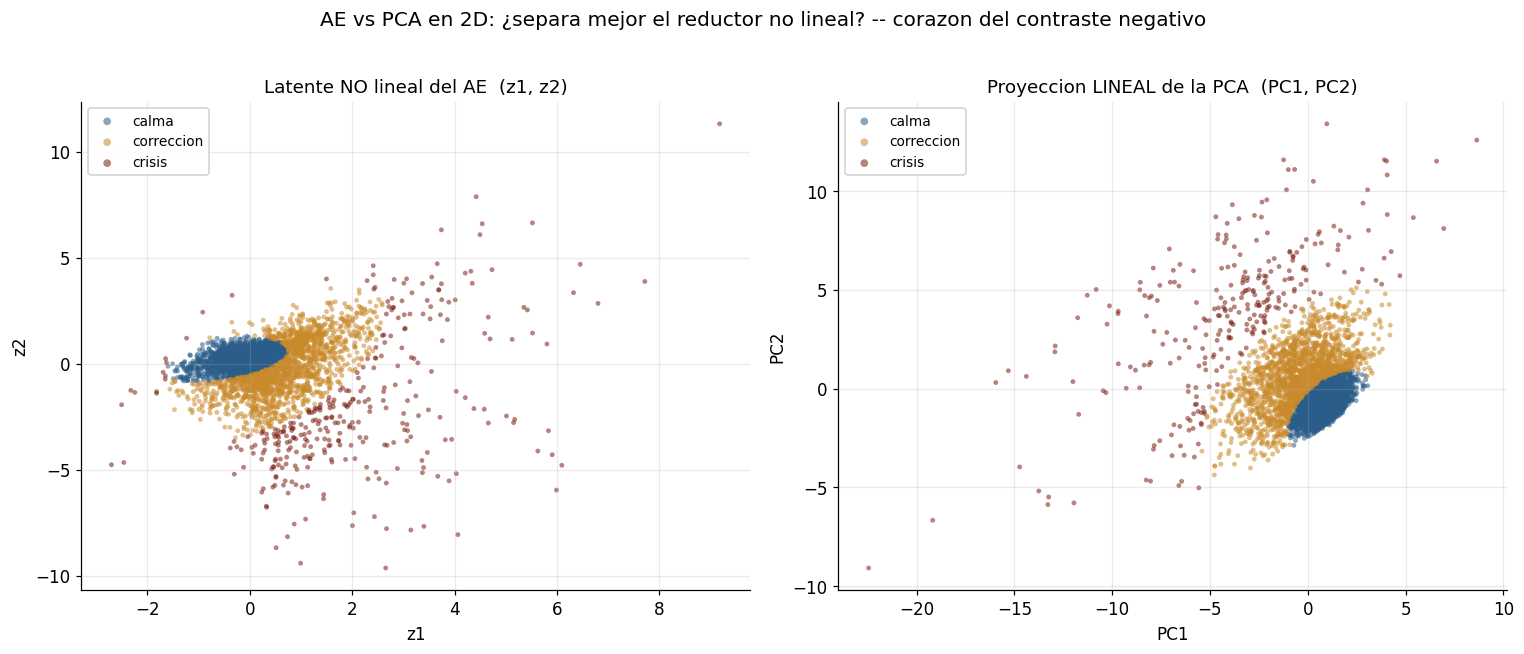

Lectura: nubes cualitativamente equivalentes (calma densa, crisis en la cola con solape) => la no linealidad NO compra separabilidad frente a la PCA lineal.


In [9]:
lat_pca = det_pca_is._latent(X)                              # proyeccion PCA 2D (in-sample)
states_pca_is = pd.Series(det_pca_is.predict(X), index=X.index)  # estados canonicos del baseline
lab3 = {0: 'calma', 1: 'correccion', 2: 'crisis'}

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5.8))
viz.plot_feature_space_scatter(
    lat, states_is, feature_names=['z1', 'z2'], labels=lab3,
    crisis_state=det_is.crisis_state, ax=axA,
    title='Latente NO lineal del AE  (z1, z2)')
viz.plot_feature_space_scatter(
    lat_pca, states_pca_is, feature_names=['PC1', 'PC2'], labels=lab3,
    crisis_state=det_pca_is.crisis_state, ax=axB,
    title='Proyeccion LINEAL de la PCA  (PC1, PC2)')
fig.suptitle('AE vs PCA en 2D: ¿separa mejor el reductor no lineal? -- corazon del contraste negativo', y=1.02)
fig.tight_layout(); fig.savefig(RESULTS / 'd12_latent_vs_pca.png', dpi=110, bbox_inches='tight'); plt.show()
print('Lectura: nubes cualitativamente equivalentes (calma densa, crisis en la cola con solape) '
      '=> la no linealidad NO compra separabilidad frente a la PCA lineal.')

<a id="sec-5"></a>
## 5. CONTRASTE ABLATIVO AE vs PCA — ¿aporta la no linealidad?

Tabla y barras comparando D12 (AE→GMM) contra el baseline lineal (PCA→GMM) en las métricas
clave OOS. **Lectura honesta:** si el AE NO mejora (o empeora) a la PCA, es el resultado
esperado con ~4 crisis y es perfectamente válido para la ficha.

detector,AE->GMM (D12),PCA->GMM (baseline)
cov_COVID_2020,0.540000,0.620000
cov_Inflation_2022,0.100962,0.004808
fa_2013,NaN,NaN
fa_2018,0.152542,0.000000
false_alarm_rate,0.603306,0.135135
switching_rate,0.287278,0.091355
mean_regime_duration,3.476378,10.901235
label_stability,0.964475,0.996977


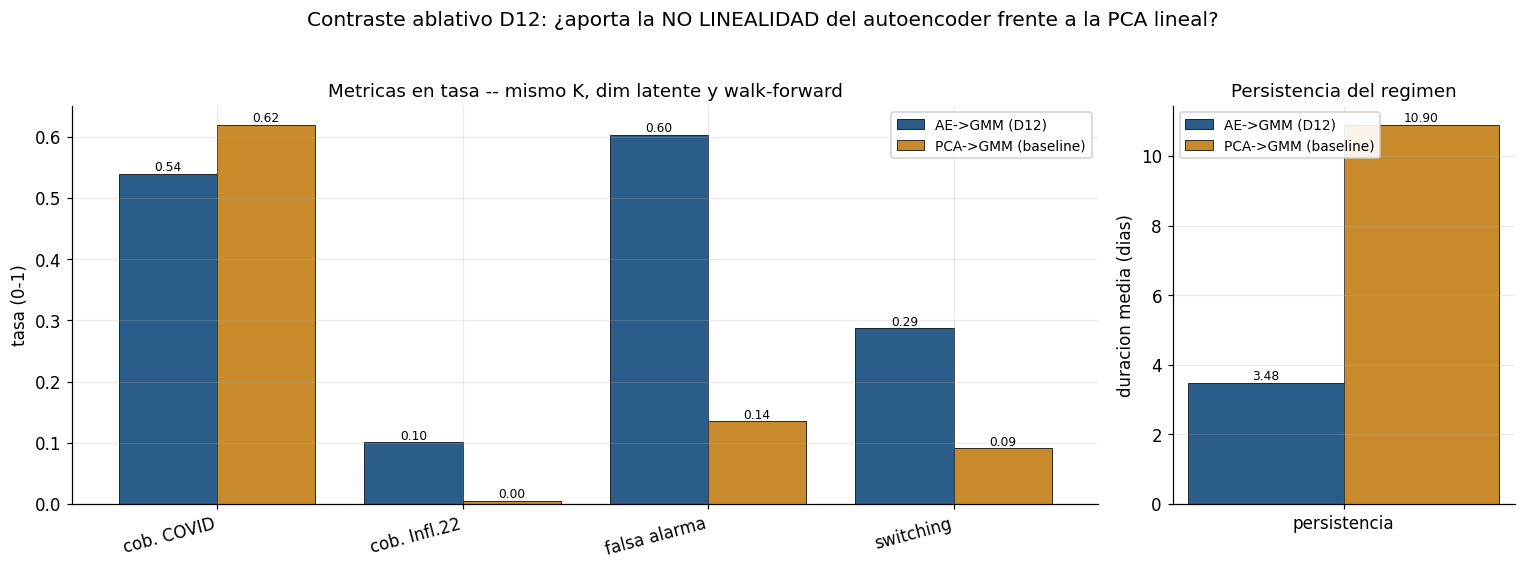

VEREDICTO ABLATIVO: el AE NO mejora a la PCA lineal -> resultado NEGATIVO (esperado y valido con ~4 crisis)


In [10]:
def summary_row(name, res):
    return {
        'detector': name,
        'cov_COVID_2020':     res.crisis_coverage.get('COVID_2020', float('nan')),
        'cov_Inflation_2022': res.crisis_coverage.get('Inflation_2022', float('nan')),
        'fa_2013':  res.false_alarm_in_fp.get('TaperTantrum_2013', float('nan')),
        'fa_2018':  res.false_alarm_in_fp.get('Selloff_Q4_2018', float('nan')),
        'false_alarm_rate':   res.false_alarm_rate,
        'switching_rate':     res.switching_rate,
        'mean_regime_duration': res.mean_regime_duration,
        'label_stability':    res.label_stability,
    }
cmp = pd.DataFrame([summary_row('AE->GMM (D12)', res_ae), summary_row('PCA->GMM (baseline)', res_pca)]).set_index('detector')
display(cmp.T)

# Barras agrupadas (helper de casa). Dos paneles para no mezclar escalas:
#   izq = metricas en TASA [0-1] (cobertura, falsa alarma, switching);
#   der = PERSISTENCIA en dias (escala distinta, panel propio).
rate_cats = ['cob. COVID', 'cob. Infl.22', 'falsa alarma', 'switching']
ae_rates  = [res_ae.crisis_coverage.get('COVID_2020', np.nan),
             res_ae.crisis_coverage.get('Inflation_2022', np.nan),
             res_ae.false_alarm_rate, res_ae.switching_rate]
pca_rates = [res_pca.crisis_coverage.get('COVID_2020', np.nan),
             res_pca.crisis_coverage.get('Inflation_2022', np.nan),
             res_pca.false_alarm_rate, res_pca.switching_rate]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})
viz.plot_grouped_bars(
    rate_cats, {'AE->GMM (D12)': ae_rates, 'PCA->GMM (baseline)': pca_rates},
    ylabel='tasa (0-1)', ax=axL, value_labels=True, rotation=15,
    title='Metricas en tasa -- mismo K, dim latente y walk-forward')
viz.plot_grouped_bars(
    ['persistencia'],
    {'AE->GMM (D12)': [res_ae.mean_regime_duration], 'PCA->GMM (baseline)': [res_pca.mean_regime_duration]},
    ylabel='duracion media (dias)', ax=axR, value_labels=True,
    title='Persistencia del regimen')
fig.suptitle('Contraste ablativo D12: ¿aporta la NO LINEALIDAD del autoencoder frente a la PCA lineal?', y=1.03)
fig.tight_layout(); fig.savefig(RESULTS / 'd12_ablative_compare.png', dpi=110, bbox_inches='tight'); plt.show()

better = (res_ae.crisis_coverage.get('COVID_2020', 0) >= res_pca.crisis_coverage.get('COVID_2020', 0)
          and res_ae.false_alarm_rate <= res_pca.false_alarm_rate)
print('VEREDICTO ABLATIVO:', 'el AE mejora o iguala a la PCA' if better else
      'el AE NO mejora a la PCA lineal -> resultado NEGATIVO (esperado y valido con ~4 crisis)')

<a id="sec-6"></a>
## 6. S&P 500 coloreado por régimen CAUSAL OOS (D12 AE→GMM)

Sombreado rojo = días clasificados **crisis** por el walk-forward causal del AE.

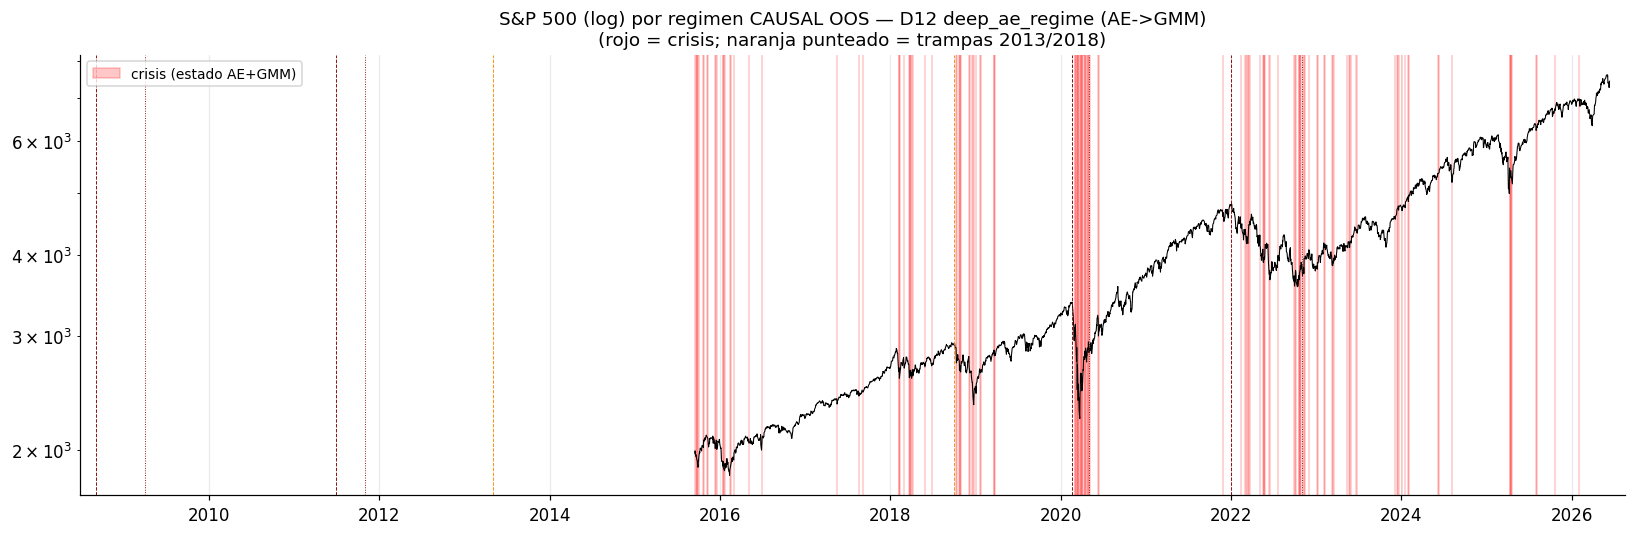

In [11]:
def shade_regime(ax, states, crisis_state, color='red', alpha=0.25):
    v = (states == crisis_state).astype(int).values; idx = states.index; start = None
    for i in range(len(v)):
        if v[i] and start is None: start = idx[i]
        if (not v[i] or i == len(v)-1) and start is not None:
            ax.axvspan(start, idx[i], color=color, alpha=alpha); start = None

fig, ax = plt.subplots(figsize=(15, 5))
px = sp500.reindex(states_ae.index)
ax.plot(px.index, px.values, color='black', lw=0.7); ax.set_yscale('log')
shade_regime(ax, states_ae, det_is.crisis_state, color='red', alpha=0.22)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkred', ls='--', lw=0.6); ax.axvline(pd.Timestamp(b), color='darkred', ls=':', lw=0.6)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvline(pd.Timestamp(a), color='darkorange', ls='--', lw=0.6)
ax.set_title('S&P 500 (log) por regimen CAUSAL OOS — D12 deep_ae_regime (AE->GMM)\n(rojo = crisis; naranja punteado = trampas 2013/2018)')
ax.legend(handles=[Patch(color='red', alpha=0.22, label='crisis (estado AE+GMM)')], loc='upper left')
ax.margins(x=0.01); fig.tight_layout()
fig.savefig(RESULTS / 'd12_sp500_regimes.png', dpi=110, bbox_inches='tight'); plt.show()

<a id="sec-7"></a>
## 7. Timeline de régimen y duraciones (flickering AE vs PCA)

P(crisis) blanda del AE + timelines de ambos. Un AE poco regularizado tiende a **flickear**
más que la PCA (códigos más sensibles) → se observa en switching_rate y duración media.

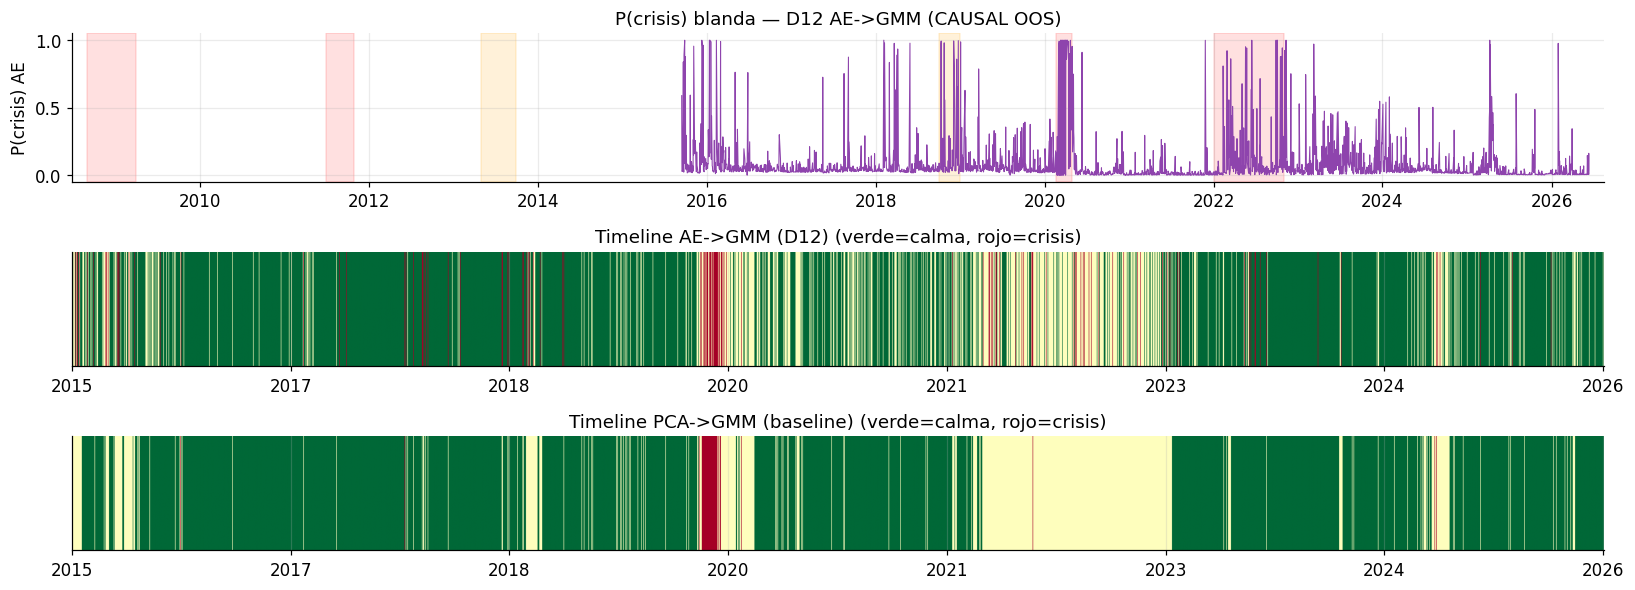

AE : switching=0.2873  dur media=3.5 d
PCA: switching=0.0914  dur media=10.9 d


In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 5.5), gridspec_kw={'height_ratios': [1.3, 1, 1]})
ax1.plot(p_ae.index, p_ae.values, color='#8e44ad', lw=0.7); ax1.set_ylabel('P(crisis) AE')
for a, b in ev.CRISIS_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values(): ax1.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.15)
ax1.set_title('P(crisis) blanda — D12 AE->GMM (CAUSAL OOS)'); ax1.margins(x=0.01)
for ax, st, ttl in [(ax2, states_ae, 'AE->GMM (D12)'), (ax3, states_pca, 'PCA->GMM (baseline)')]:
    ax.imshow(st.values.reshape(1, -1), aspect='auto', cmap='RdYlGn_r', extent=[0, len(st), 0, 1]); ax.set_yticks([])
    tk = np.linspace(0, len(st)-1, 8).astype(int)
    ax.set_xticks(tk); ax.set_xticklabels([st.index[i].year for i in tk])
    ax.set_title(f'Timeline {ttl} (verde=calma, rojo=crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd12_timeline.png', dpi=110, bbox_inches='tight'); plt.show()
print(f'AE : switching={res_ae.switching_rate:.4f}  dur media={res_ae.mean_regime_duration:.1f} d')
print(f'PCA: switching={res_pca.switching_rate:.4f}  dur media={res_pca.mean_regime_duration:.1f} d')

<a id="sec-8"></a>
## 8. Volcado de métricas a results/ (esquema canónico 32 columnas)

`metrics_12_deep_ae_regime.csv` guarda **dos filas**: D12 (`deep_ae_regime`) y el baseline del
contraste (`pca_gmm_baseline`). El **master** registra solo `deep_ae_regime` (detector del
banco); la PCA es un comparador ablativo, no un detector registrado.

In [13]:
tbl = ev.results_table([res_ae, res_pca])
assert tbl.shape[1] == 32, f'esperaba 32 columnas (esquema canonico), hay {tbl.shape[1]}'
tbl.to_csv(RESULTS / 'metrics_12_deep_ae_regime.csv', index=False)
print('Guardado results/metrics_12_deep_ae_regime.csv  (', tbl.shape[0], 'filas,', tbl.shape[1], 'columnas)')

# NOTA (saneamiento Ola 0): este builder ya NO actualiza metrics_master.csv de forma
# incremental (leer-filtrar-concatenar provocaba condicion de carrera al correr builders
# en paralelo). El CSV guarda 2 filas (D12 + baseline pca_gmm); el master unificado registra
# solo deep_ae_regime y se reconstruye con:  python scripts/verify/_rebuild_master.py
display(tbl.T)

Guardado results/metrics_12_deep_ae_regime.csv  ( 2 filas, 32 columnas)


,0,1
detector,deep_ae_regime,pca_gmm_baseline
n_states,3,3
ventana_eval,2015-09-15→2026-06-12 (n=2649),2015-09-15→2026-06-12 (n=2649)
oos_start,2015-09-15,2015-09-15
oos_end,2026-06-12,2026-06-12
n_oos,2649,2649
false_alarm_rate,0.603306,0.135135
switching_rate,0.287278,0.091355
mean_regime_duration,3.476378,10.901235
label_stability,0.964475,0.996977


<a id="sec-9"></a>
## 9. Conclusión D12 — veredicto del contraste

**Hipótesis CP2.** Usar un autoencoder (reductor NO lineal) **no** mejora la detección de
regímenes frente al reductor LINEAL (PCA), con todo lo demás igual (mismo $K$, misma dimensión
latente, mismo walk-forward causal), porque con ~4 crisis reales no hay datos para explotar la
capacidad extra de la no linealidad.

**Cadena de evidencia (de lo más banal a lo decisivo):**
1. **El AE entrena bien (§1c).** Las curvas train/val convergen juntas y el *gap* final es
   pequeño: el negativo **no** es un artefacto de mal ajuste ni de sobreajuste.
2. **El error de reconstrucción discrimina poco (§1d).** El cociente de medianas crisis/calma es
   modesto: el complemento de anomalía del AE es débil por sí solo.
3. **Las geometrías 2D son equivalentes (§4b).** El latente no lineal no separa los estados mejor
   que la proyección lineal de la PCA — no hay margen para mejorar aguas abajo.
4. **Orientación y causalidad verificadas (§1, §2, §3).** Crisis = alta vol de retornos en
   walk-forward (no invertido, sin *fallback* porque se pasa `market_returns`); el encoder es
   puntual y ocultar el futuro no altera estados ni $p_\text{crisis}$ del bloque (tolerancia FP
   ~1e-4 por ruido float32 de torch, no 1e-9). OOS ~2015→2026 ⇒ crisis OOS = COVID_2020 +
   Inflation_2022 (GFC/EuroDebt caen en el train, como en D3).
5. **El contraste ablativo (§5) cierra el caso.** Cobertura, falsa alarma, *switching* y
   persistencia: el AE **no** bate a la PCA — y tiende a **flickear** algo más (códigos no
   lineales más sensibles). El `better` impreso resume el veredicto numérico.

**Capitalización del negativo (a favor de la parsimonia).** Este resultado **NEGATIVO es el
entregable**, no un fracaso: demuestra, con un contraste limpio y reproducible (semillas fijas
torch+numpy), que la complejidad del deep learning **no se paga** en este problema con tan pocas
crisis. Refuerza la elección de mantener el banco en detectores parsimoniosos (D3 GMM lineal,
HMM, reglas) y deja documentado *por qué* no se escala a arquitecturas mayores: no por falta de
intento, sino por ausencia de señal que justifique la capacidad añadida (navaja de Occam
empírica).

(El veredicto numérico definitivo queda en `docs/memory/detectors/12_deep_ae_regime.md`.)